<a href="https://colab.research.google.com/github/WiebkePetersen/TeachingTransformer/blob/main/Teaching_sampling_strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Which token to generate next?

This notebook is based on this [notebook](https://drive.google.com/file/d/14OyZRyUE3iVTVK5MG8ZyXReuzZwgg5Xg/view) by *AI Coffee Break with Letitia
AI Coffee Break with Letitia* (see her [video](https://www.youtube.com/watch?v=o-_SZ_itxeA) as well).

Generative Sprachmodelle müssen in jedem Schritt entscheiden, welches Token als nächstes generiert werden soll (basierend auf dem Input Prompt und den zuvor generierten Tokens).

**Erinnerung:** Der Output in jedem Schritt ist eine mit Softmax erzeugte Wahrscheinlichkeitsverteilung über das gesamte Tokenalphabet.

Wir laden zunächst ein generierendes Sprachmodell für die deutsche Sprache. Wir nehmen ein relativ kleines Modell für Demonstrationszwecke: [dbmdz/german-gpt2](https://huggingface.co/dbmdz/german-gpt2)

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Load model and tokenizer
checkpoint = "dbmdz/german-gpt2"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForCausalLM.from_pretrained(checkpoint)

print("\n**Model configuration:**")
model.eval()


config.json:   0%|          | 0.00/865 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.43M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/510M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: dbmdz/german-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



**Model configuration:**


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50265, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50265, bias=False)
)

Es folgt der Input Prompt:

In [3]:

# Input prompt
prompt = "Der Hund rannte freudig bellend über die"

# Tokenize input
inputs = tokenizer(prompt, return_tensors="pt")


## greedy decoding & simple sampling

Die einfachste Strategie ist jeweils das wahrscheinlichste Token generieren zu lassen. Diese deterministische Strategie heißt **greedy decoding**.

In [16]:
# Generate using greedy decoding
output_ids = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=50, # maximal 50 new tokens will be generated
    do_sample=False,  # <-- this disables sampling → greedy decoding
    pad_token_id=tokenizer.eos_token_id
)

# Decode and print
output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(output_text)

Der Hund rannte freudig bellend über die Straße.
Die Polizei hat die Ermittlungen aufgenommen.
Die Polizei in der Region Hannover hat am Donnerstagmorgen einen Mann festgenommen, der in der Nacht zu Samstag in einem Drogeriemarkt in der Innenstadt eine Frau mit einem Messer bedroht haben soll.
Die


Greedy Decoding ist deterministisch; mehrfaches Anwenden führt immer zum selben Ergebnis.

In [4]:

# Generate using greedy decoding
for i in range(3):
  print(f"\n**Generation {i+1}**")
  output_ids = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=50, # maximal 50 new tokens will be generated
    do_sample=False,  # <-- this disables sampling → greedy decoding
    pad_token_id=tokenizer.eos_token_id
  )

  # Decode and print
  output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
  print(output_text)


**Generation 1**
Der Hund rannte freudig bellend über die Straße.
Die Polizei hat die Ermittlungen aufgenommen.
Die Polizei in der Region Hannover hat am Donnerstagmorgen einen Mann festgenommen, der in der Nacht zu Samstag in einem Drogeriemarkt in der Innenstadt eine Frau mit einem Messer bedroht haben soll.
Die

**Generation 2**
Der Hund rannte freudig bellend über die Straße.
Die Polizei hat die Ermittlungen aufgenommen.
Die Polizei in der Region Hannover hat am Donnerstagmorgen einen Mann festgenommen, der in der Nacht zu Samstag in einem Drogeriemarkt in der Innenstadt eine Frau mit einem Messer bedroht haben soll.
Die

**Generation 3**
Der Hund rannte freudig bellend über die Straße.
Die Polizei hat die Ermittlungen aufgenommen.
Die Polizei in der Region Hannover hat am Donnerstagmorgen einen Mann festgenommen, der in der Nacht zu Samstag in einem Drogeriemarkt in der Innenstadt eine Frau mit einem Messer bedroht haben soll.
Die


Die Wahl des jeweils wahrscheinlichsten Tokens führt schnell in eine Schleife. Besser ist es daher eine intelligentere Strategie für die Wahl des Tokens zu wählen.

Zunächst schauen wir uns an, wie die Softmaxverteilung aussieht

In [5]:

import torch
import torch.nn.functional as F

# Generate with scores enabled
output = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=50,
    do_sample=False,  # Greedy decoding
    pad_token_id=tokenizer.eos_token_id,
    return_dict_in_generate=True,  # Necessary to get the scores object
    output_scores=True            # Returns the prediction logits for each step
)

# 1. Decode and print the text (as you did before)
# Since return_dict_in_generate=True, the IDs are inside output.sequences
output_ids = output.sequences
output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("Generated Text:")
print(output_text)
print("\n" + "="*40 + "\n")

# 2. Extract Softmax distribution for the 1st generated token
# output.scores is a tuple containing logits for each generated step.
# Index 0 corresponds to the very first new token.
first_token_logits = output.scores[0][0]  # Shape: [vocab_size]

# Calculate the Softmax probabilities
softmax_distribution = F.softmax(first_token_logits, dim=-1)

# Display the top k candidates for this first word
top_k = 10
top_probabilities, top_indices = torch.topk(softmax_distribution, top_k)

print(f"Top {top_k} Softmax probabilities for the 1st generated token:")
for prob, idx in zip(top_probabilities, top_indices):
    token = tokenizer.decode([idx.item()])
    print(f"'{token}' -> {prob.item() * 100:.2f}%")

Generated Text:
Der Hund rannte freudig bellend über die Straße.
Die Polizei hat die Ermittlungen aufgenommen.
Die Polizei in der Region Hannover hat am Donnerstagmorgen einen Mann festgenommen, der in der Nacht zu Samstag in einem Drogeriemarkt in der Innenstadt eine Frau mit einem Messer bedroht haben soll.
Die


Top 10 Softmax probabilities for the 1st generated token:
' Straße' -> 34.93%
' Wiese' -> 13.95%
' Bühne' -> 4.70%
' Fahrbahn' -> 1.45%
' Weide' -> 1.27%
' Kreuzung' -> 1.26%
' Strecke' -> 1.14%
' Brücke' -> 0.78%
' St' -> 0.76%
' beiden' -> 0.73%


Als nächstes testen wir einfaches Sampling über alle Wörter des Vokabulars:

In [17]:
# Generate using plain random sampling (no top-k or top-p)
output_ids = model.generate(
      input_ids=inputs.input_ids,
      attention_mask=inputs.attention_mask,
      max_new_tokens=50,
      do_sample=True,      # enable sampling
      temperature=1.0,     # keep normal distribution shape
      pad_token_id=tokenizer.eos_token_id
)
print(tokenizer.decode(output_ids[0], skip_special_tokens=True))

Der Hund rannte freudig bellend über die Straße. -Der Hund lief dann weg. -Ich komme zurück. -Warum geht ihr nicht aus? -Wir sehen mal, wer anruft oder im Moment nicht da ist.
Die Grünen-Abgeordnete Luise Amtsberg forderte eine klare Trennung vom Familien


Das Sampling ist nicht deterministisch:

In [18]:
# Generate using plain random sampling (no top-k or top-p)
for i in range(3):
  print(f"\n**Generation {i+1}**")
  output_ids = model.generate(
      input_ids=inputs.input_ids,
      attention_mask=inputs.attention_mask,
      max_new_tokens=50,
      do_sample=True,      # enable sampling
      temperature=1.0,     # keep normal distribution shape
      pad_token_id=tokenizer.eos_token_id
  )
  print(tokenizer.decode(output_ids[0], skip_special_tokens=True))


**Generation 1**
Der Hund rannte freudig bellend über die Straße, bis er aus seinem Versteck wieder herauskam.
Die deutsche Wirtschaft hofft, dass sich der Handelsstreit zwischen den USA und China im Laufe des Jahres und im Handelsverlauf wohl mit positiven Signalen entleeren wird.
Für die Zeit ab

**Generation 2**
Der Hund rannte freudig bellend über die Strasse.
Auf diesem Bild wurde die Lage der Tiere deutlich.
Dies ist das Bild und im Text ein wenig zu sehr als Darstellung einer Hundeklau-Aktion mit folgenden Worten beschrieben:
Hier die Situation die durch die Jagd entstehen, also zu

**Generation 3**
Der Hund rannte freudig bellend über die Straße.
Dürfen wir auch?
- Ja, selbstverständlich.
Vielen Dank noch mal von Ihnen für Ihre Arbeit.
Das ist ein tolles Auto.
- Was für eine Arbeit?
Oh nein, nicht zu fassen.
Ich habe


## top-k, top-p and min-p sampling


Statt aus dem gesamten Vokabular zu wählen wird im **top-k sampling** aus den k wahrscheinlichsten Wörtern gewählt (k=1 ist entsprechend greedy sampling):

In [19]:
# Generate using top-k sampling
output_ids = model.generate(
      input_ids=inputs.input_ids,
      attention_mask=inputs.attention_mask,
      max_new_tokens=50,
      do_sample=True,      # must be True for top-k to work
      top_k=1,              # only sample from the top 1 tokens (=greedy sampling)
      temperature=1.0,     # optional: lower for safer output
      pad_token_id=tokenizer.eos_token_id
)
print(tokenizer.decode(output_ids[0], skip_special_tokens=True))

Der Hund rannte freudig bellend über die Straße.
Die Polizei hat die Ermittlungen aufgenommen.
Die Polizei in der Region Hannover hat am Donnerstagmorgen einen Mann festgenommen, der in der Nacht zu Samstag in einem Drogeriemarkt in der Innenstadt eine Frau mit einem Messer bedroht haben soll.
Die


Wiederholtes Generieren mit k>1

In [7]:
for i in range(3):
  print(f"\n**Generation {i+1}**")
  # Generate using top-k sampling
  output_ids = model.generate(
      input_ids=inputs.input_ids,
      attention_mask=inputs.attention_mask,
      max_new_tokens=50,
      do_sample=True,      # must be True for top-k to work
      top_k=10,            # only sample from the top 10 tokens
      temperature=1.0,     # optional: lower for safer output
      pad_token_id=tokenizer.eos_token_id
  )
  print(tokenizer.decode(output_ids[0], skip_special_tokens=True))


**Generation 1**
Der Hund rannte freudig bellend über die Wiese, die ihn in den Garten zurückbrachte.
Und die sind ja auch da.
Die werden sich dann auch an die Vorgaben halten.
Die neue Technik soll die Arbeit von der Straße auf den See und die Uferwege verlagern und gleichzeitig

**Generation 2**
Der Hund rannte freudig bellend über die Straße, bis der Fahrer die Polizisten anhielt.
Der "Gault &amp; Grill"-Guide
"Das ist eine gute Idee", sagt die Frau.
Es gibt auch viele, die das noch nicht so sehen.
Das ist

**Generation 3**
Der Hund rannte freudig bellend über die Straße.
Die Polizei hatte bereits im vergangenen Jahr Ermittlungen aufgenommen.
Ein Teil der Fläche ist als Sonderbaufläche ausgewiesen - der andere Teil als Sonderbaufläche.
Die SPD sei für die Einführung von Ankerzentren.
Der Verein ist ein wichtiger


Die Wahrscheinlichkeitsverteilung kann sehr unterschiedlich aussehen. Mal gibt es sehr viele relativ wahrscheinliche Tokens und mal konzentrieren wenige Tokens fast die gesamte Wahrscheinlichkeit auf sich, so dass andere hochgerankte Tokens bereits sehr unwahrscheinlich sind. Um dem gerecht zu werden, wählt im **top-p sampling** (auch **Nucleus Sampling** genannt) das Modell das nächste Token nur aus der kleinstmöglichen Gruppe von Token aus, deren kumulierte Softmax-Wahrscheinlichkeiten zusammen einen gesetzten Grenzwert p erreichen.

In [8]:
for i in range(3):
  print(f"\n**Generation {i+1}**")
  # Generate with top-p sampling
  output_ids = model.generate(
      input_ids=inputs.input_ids,
      attention_mask=inputs.attention_mask,
      max_new_tokens=50,
      do_sample=True,
      top_p=0.5,
      temperature=1.0,
      pad_token_id=tokenizer.eos_token_id
  )
  print(tokenizer.decode(output_ids[0], skip_special_tokens=True))



**Generation 1**
Der Hund rannte freudig bellend über die Straße, als die Frau auf ihn zukam.
"Das war ein sehr guter Test", sagte der Kapitän.
Der erste Eindruck: Die neue Regierung wird von den Grünen, die am Freitag den Koalitionsvertrag unterzeichnet haben, getragen.
Das ist eine

**Generation 2**
Der Hund rannte freudig bellend über die Straße.
Die Stadt will mit dem neuen Konzept den Verkehr auf der viel befahrenen Bahntrasse von der Borsigstraße in die Straße "Am Bahnhof" umleiten.
Der "Gigant" hat sich im Vorfeld für die Aktion

**Generation 3**
Der Hund rannte freudig bellend über die Straße.
Die Polizei hatte den Mann nach dem Diebstahl am Sonntag festgenommen.
In der vergangenen Woche hatte die Polizei den mutmaßlichen Täter gefasst.
Der Angeklagte hatte in der Verhandlung erklärt, dass er mit dem Angeklagten in einem persönlichen Gespräch nicht über die Situation


Beim **min-P sampling** werden alle Token aussortiert, deren Softmax-Wahrscheinlichkeit unter einem bestimmten Prozentsatz (z. B. 5 %) der Wahrscheinlichkeit des absoluten Top-Tokens liegt.

In [9]:
# Generate with min-p sampling
for i in range(3):
  print(f"\n**Generation {i+1}**")
  output_ids = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=50,
    do_sample=True,
    min_p=0.05,
    temperature=1.5,
    pad_token_id=tokenizer.eos_token_id
  )
  print(tokenizer.decode(output_ids[0], skip_special_tokens=True))



**Generation 1**
Der Hund rannte freudig bellend über die Straße.
Und wenn sich niemand finden ließ?
Sie sind weg, und am nächsten Morgen, wie?
Nein, sie hatten sich in meine Arbeit eingehackt.
Es war nur ein kleiner Schlag gegen einen kleinen Hund.
(R

**Generation 2**
Der Hund rannte freudig bellend über die Wiese und begann den Menschen zu suchen.
Aufgabe eines Museums
Seit dem 29. Oktober ist die Straße gesperrt.
Die Staatsanwaltschaft Berlin habe mit ihrer Haftverlängerung zwar noch keine Gewissheit in diesem Zusammenhang erlangt, man habe aber durchblicken lassen, "

**Generation 3**
Der Hund rannte freudig bellend über die Brücke im Stadtteil Meschenich, als er bemerkte, dass er seine Verfolger, welche mit ihm fliehen konnten, bemerkt hatte, bis sie einen Zwischenhalt in den gegenüberliegenden Häusern einlegten.
Auch der andere Zeuge, der das Unglück am Sonntagvormittag zunächst


Vergleich von min-p und top-p sampling:
min-p sampling passt sich der Verteilung besser an.

Szenario 1 (`top-p=0.95`, `min-p=0.05`): 1 sehr wahrscheinlichs Token (0.9) gefolgt von 100 Tokens, die alle sehr unwahrscheinlich sind (`<0.001`). min-p wählt keines der unwahrscheinlichen Tokens. top-p wählt stur aus dem wahrscheinlichsten sowie ca. 50 der unwahrscheinlichen.

Szenario 2 (`p=0.95`, `min-p=0.05`): die ersten 100 Tokens haben eine Wahrscheinlichkeit von ca. 0.01 und die folgenden von <0.0001. min-p wählt aus den 100 ersten Token. top-p wählt aus den ersten 95 Token, obwohl die folgenden 5 ähnlich wahrscheinlich sind.

Teste Input Prompts wie: "Das Ergebnis von 2+2 ist " oder "Ein seltener Name ist "

## temperature

Der **temperature**-Parameter steuert wie steil die Softmax-Verteilung ist. Vor der Anwendung der Softmax-Funktion werden alle Werte durch `temperature` geteilt.

Ist `temperature < 1`, so wird die Verteilung steiler, und für  `temperature > 1` wird sie flacher.

Eine hohe Temperatur führt also dazu, dass in einem sampling-Verfahren, das Softmax nutzt, die Wahrscheinlichkeit von weniger wahrscheinlichen Fortsetzungen hochgesetzt wird. Der textuelle Output wird dadurch diverser aber möglicherweise auch *falscher*.

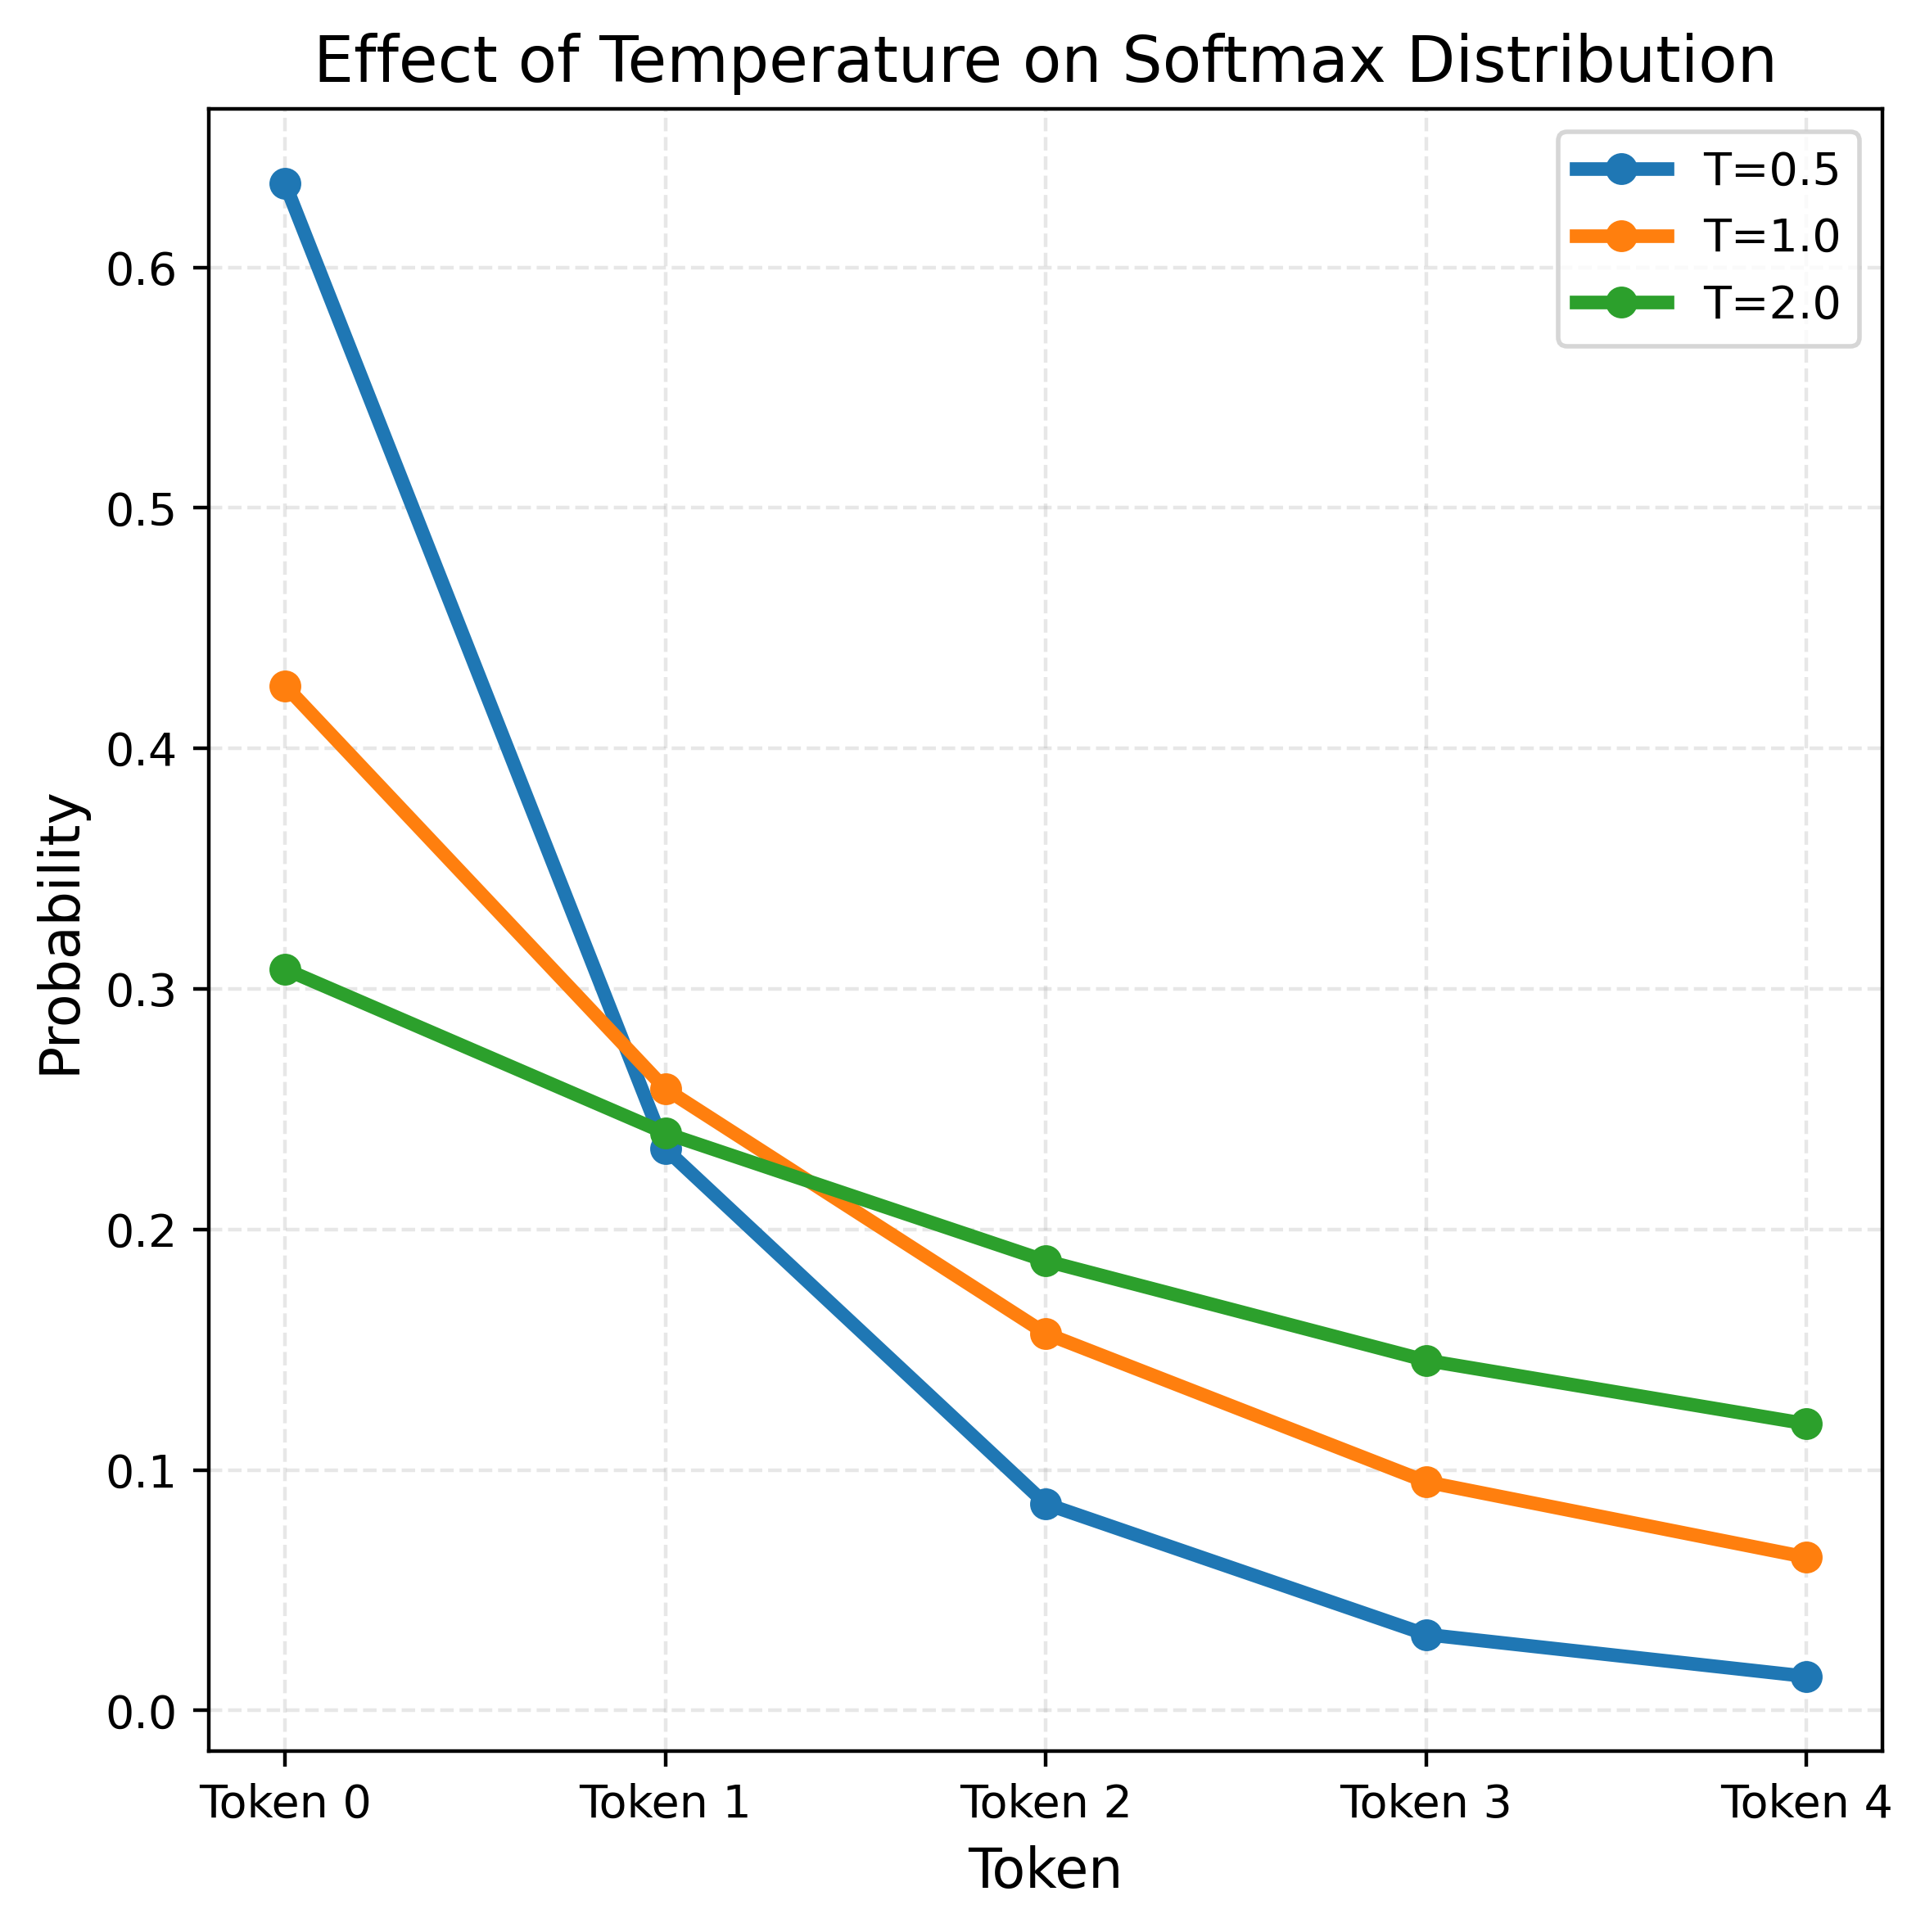

In [10]:
import numpy as np
import matplotlib.pyplot as plt


# Simulated logits (e.g., from a language model)
logits = np.array([2.0, 1.5, 1.0, 0.5, 0.1])

# Temperature values to test
temperatures = [0.5, 1.0, 2.0]

# Softmax function with temperature
def softmax_with_temp(logits, temp):
    scaled = logits / temp
    exps = np.exp(scaled - np.max(scaled))  # for numerical stability
    return exps / np.sum(exps)

# Plotting
plt.figure(figsize=(6, 6), dpi=400)
token_labels = [f"Token {i}" for i in range(len(logits))]

for temp in temperatures:
    probs = softmax_with_temp(logits, temp)
    plt.plot(token_labels, probs, marker='o', label=f'T={temp}', linewidth=3)

plt.title("Effect of Temperature on Softmax Distribution", fontsize=14)
plt.xlabel("Token", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Generate with temperature

temperature = [0.5, 1.0, 2.0]

for t in temperature:
  print(f"\n**Temperature {t}**")
  output_ids = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=50,
    do_sample=True,
    temperature=t,
    pad_token_id=tokenizer.eos_token_id
  )
  print(tokenizer.decode(output_ids[0], skip_special_tokens=True))



**Temperature 0.5**
Der Hund rannte freudig bellend über die Straße, um den Jungen zu retten.
Der Hund wurde von einem anderen Hund gerettet.
Die Polizei hat uns gebeten, das Haus zu räumen.
Ich bin froh, dass wir es gefunden haben.
Es ist ein schöner Anblick.
Wir

**Temperature 1.0**
Der Hund rannte freudig bellend über die Straße.
Vorne fehlte nicht viel, im Mittelfeld spielten nur fünf Ausländer im Kader. © getty
Der Ex-Profi und langjährige Werder-Trainer blickt zurück, als wäre er am Montag bereits zu Hause gewesen.
Seit 2009 wird in

**Temperature 2.0**
Der Hund rannte freudig bellend über die Schulter und rüttelte dabei ganz unvermittelt über ihre Fersen und unter dem Mantel von dem noch gar jungen, etwas zu schwach gewartexpletterten Rüden. Der andere Hündchih sah noch auf ihre Lippen hinaufzurutschen,


## beam search decoding

**Beam Search** ist ein deterministisches Decoding-Verfahren, das bei der Textgenerierung nicht nur das jeweils einzelne beste nächste Wort im Blick hat (wie das kurzsichtige Greedy Decoding), sondern stattdessen die $k$ vielversprechendsten Sequenz-Pfade (die sogenannten Beams) parallel generiert.

Am Ende gewinnt die Sequenz, die über den gesamten Verlauf hinweg die höchste Gesamtwahrscheinlichkeit erzielt hat.

In [13]:
# Generate with beam search

for i in range(3):
  print(f"\n**Generation {i+1}**")
  # Generate using top-k sampling
  output_ids = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=50,
    do_sample=False,         # Disables sampling (Beam Search is deterministic)
    num_beams=5,             # Number of parallel paths (beams) to track
    early_stopping=True,     # Optional: Stops generation when all beams hit EOS
    pad_token_id=tokenizer.eos_token_id
    )
  print(tokenizer.decode(output_ids[0], skip_special_tokens=True))



**Generation 1**
Der Hund rannte freudig bellend über die Straße.
"Wir haben in den letzten Jahren viel erreicht, aber es gibt noch viel zu tun", sagte er.
"Es ist eine große Ehre für mich, hier zu sein", sagte er.
"Es ist eine große Ehre für mich

**Generation 2**
Der Hund rannte freudig bellend über die Straße.
"Wir haben in den letzten Jahren viel erreicht, aber es gibt noch viel zu tun", sagte er.
"Es ist eine große Ehre für mich, hier zu sein", sagte er.
"Es ist eine große Ehre für mich

**Generation 3**
Der Hund rannte freudig bellend über die Straße.
"Wir haben in den letzten Jahren viel erreicht, aber es gibt noch viel zu tun", sagte er.
"Es ist eine große Ehre für mich, hier zu sein", sagte er.
"Es ist eine große Ehre für mich


### Sampled Beam Search (Multinomial Beam Search)

Während das klassische Beam Search seine Pfade deterministisch nur mit den mathematisch wahrscheinlichsten Token erweitert, zieht Sampled Beam Search diese Pfadverlängerungen zufällig (per Sampling) aus der Wahrscheinlichkeitsverteilung, behält danach aber wie im klassischen Beam Search strikt die $k$ besten Gesamtpfade.

In [15]:
# Generate with beam search

for i in range(3):
  print(f"\n**Generation {i+1}**")
  # Generate using top-k sampling
  output_ids = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=50,
    num_beams=5,             # Number of parallel paths (beams) to track
    early_stopping=True,     # Optional: Stops generation when all beams hit EOS
    do_sample=True,         # Sampled Beam Search
    temperature=0.8,
    top_p=0.92,          # Cut away the long tail
    top_k=50,            # Restrict to top 50
    pad_token_id=tokenizer.eos_token_id
    )
  print(tokenizer.decode(output_ids[0], skip_special_tokens=True))



**Generation 1**
Der Hund rannte freudig bellend über die Straße.
In der zweiten Hälfte des 19. Jahrhunderts, als sich die industrielle Revolution in Europa ausbreitete, wurde der Begriff "Faschismus" geprägt.
Die Polizei sucht nach Zeugen, die den Vorfall beobachtet haben oder Hinweise zu den Tätern geben

**Generation 2**
Der Hund rannte freudig bellend über die Straße.
"Es ist eine Ehre, hier zu sein", sagte er.
"Es ist eine Ehre, hier zu sein."
"Es ist eine Ehre, hier zu sein."
"Es ist eine Ehre, hier zu sein."


**Generation 3**
Der Hund rannte freudig bellend über die Straße.
"Das ist nicht das Ende der Fahnenstange, sondern das Ende der Fahnenstange", sagte der CDU-Politiker der "Bild"-Zeitung (Donnerstag).
"Wir haben in den vergangenen Jahren viel Geld in die Hand genommen, um die


**Zusammenfassung**

1.  Logits berechnen: Das Modell liefert die rohen Vorhersagewerte ($-\infty$ bis $+\infty$)
2.  Skalieren (Temperature): Die Logits werden durch den Temperatur-Wert dividiert.
2. Softmax anwenden: Die skalierten Logits werden in echte Wahrscheinlichkeiten ($0.0$ bis $1.0$, Summe = $1.0$) umgerechnet.
2. Filter anwenden (top-k / top-p): Basierend auf diesen Wahrscheinlichkeiten werden unpassende Tokens eliminiert. Die verbleibenden Tokens werden normalisiert, damit sie sich wieder zu 100 % aufsummieren.
2. Sampled Expansion: Aus dieser gefilterten Verteilung wird per Zufall ausgewählt, um die bestehenden $k$ Beams zu verlängern.
3. Pruning: Aus allen erweiterten Pfaden werden die $k$ Pfade mit der höchsten kombinierten Gesamtwahrscheinlichkeit behalten.
